# Portfolio Optimization

**Reference:** Nocedal and Wright, *Numerical Optimization*, 2nd ed. (2006), Example 16.1 (Portfolio Optimization), pp. 449--450.

This notebook is adapted from Problem 3 of Problem Set 3 in [CBE 20258: Numerical and Statistical Analysis](https://ndcbe.github.io/data-and-computing/), where it is used to practice statistical analysis. Here we use it as the course's first **convex** nonlinear program, and as the foil to the circle packing example: same solver, same course, but the answer is guaranteed to be global.


In [1]:
# This code cell installs packages on Colab

import sys

if "google.colab" in sys.modules:
    !wget "https://raw.githubusercontent.com/ndcbe/optimization/main/notebooks/helper.py"
    !wget "https://raw.githubusercontent.com/ndcbe/optimization/main/notebooks/pyomo_results.py"
    import helper

    helper.easy_install()
else:
    sys.path.insert(0, "../")
    import helper
helper.set_plotting_style()

# Extract / archive / save-the-figure plumbing, shared with the lecture handouts.
import pyomo_results as pyr


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyomo.environ as pyo
from pyomo.environ import units as u
from pyomo.util.check_units import assert_units_consistent

## The data

Historical daily *adjusted closing prices* for five years (from Yahoo! Finance) are available for the $N = 5$ market indices below. (They are market indices rather than individual stocks, but that does not change the analysis.)

| Symbol | Name |
|-|-|
| DJI | Dow Jones Industrial Average |
| GSPC | S&P 500 |
| IXIC | NASDAQ Composite |
| RUT | Russell 2000 |
| VIX | CBOE Volatility Index |


In [3]:
df_adj_close = pd.read_csv("../data/Stock_Data.csv")

print(
    f"{len(df_adj_close)} daily closing prices for {len(df_adj_close.columns)} indices"
)
df_adj_close.head()

1259 daily closing prices for 5 indices


,DJI,GSPC,IXIC,RUT,VIX
0,14447.75000,1551.689941,3235.300049,945.849976,13.74
1,14559.65039,1563.770020,3252.479980,949.820007,12.77
2,14526.16016,1562.849976,3256.520020,950.239990,13.15
3,14578.54004,1569.189941,3267.520020,951.539978,12.70
4,14572.84961,1562.170044,3239.169922,938.789978,13.58


## Step 1. Estimate the model parameters

The one-day return rate for index $i$ between days $t$ and $t+1$ is

$$
r_{t,i} = \frac{p_{t+1,i} - p_{t,i}}{p_{t,i}}
$$

where $p_{t,i}$ is the adjusted closing price. From the matrix of returns $R$ we estimate

* $\bar{r}_i$, the **average** one-day return of index $i$, and
* $\Sigma_r$, the **covariance matrix** of the one-day returns.

Notice that both are *estimated from data*. Neither was given to us. Hold that thought until the last section.


In [4]:
# One-day return rates. pct_change() computes (p_{t+1} - p_t) / p_t.
R = df_adj_close.pct_change().dropna()

# Average one-day return of each index, rbar_i [1/day]
R_avg = R.mean(axis=0)

# Covariance of the one-day returns, Sigma_ij [1/day^2]
Cov = R.cov()

print(f"{len(R)} one-day returns\n")
print("Average one-day return:")
print(R_avg)

1258 one-day returns

Average one-day return:
DJI     0.000432
GSPC    0.000454
IXIC    0.000674
RUT     0.000440
VIX     0.003718
dtype: float64


In [5]:
print("Covariance matrix:")
display(Cov.round(8))

print("\nCorrelation matrix:")
display(R.corr().round(4))

Covariance matrix:


,DJI,GSPC,IXIC,RUT,VIX
DJI,0.000059,0.000058,0.000060,0.000062,-0.000507
GSPC,0.000058,0.000060,0.000066,0.000067,-0.000536
IXIC,0.000060,0.000066,0.000082,0.000080,-0.000596
RUT,0.000062,0.000067,0.000080,0.000101,-0.000609
VIX,-0.000507,-0.000536,-0.000596,-0.000609,0.007374



Correlation matrix:


,DJI,GSPC,IXIC,RUT,VIX
DJI,1.0000,0.9657,0.8658,0.8005,-0.7703
GSPC,0.9657,1.0000,0.9395,0.8615,-0.8037
IXIC,0.8658,0.9395,1.0000,0.8793,-0.7660
RUT,0.8005,0.8615,0.8793,1.0000,-0.7045
VIX,-0.7703,-0.8037,-0.7660,-0.7045,1.0000


## Step 2. The Markowitz mean/variance model

**Given** a set of assets whose returns fluctuate, **choose** what fraction of your money to put in each so that the *variance* of the portfolio return is as small as possible, subject to achieving at least a required expected return.

**Sets.** $\mathcal{S}$ --- the assets.

**Parameters.** $\bar{r}_i$, the expected one-day return of asset $i \in \mathcal{S}$; $\Sigma_r$, the covariance matrix of the one-day returns; $\rho$, the required expected return of the portfolio.

**Variables.** $x_i$, the fraction of funds placed in asset $i$.

$$
\begin{align}
\min_{x} \quad & z := x^T \Sigma_r x && \text{variance of the portfolio return} \\
\text{s.t.} \quad & \bar{r}^T x \geq \rho && \text{achieve the required return} \\
& \sum_{i \in \mathcal{S}} x_i = 1 && \text{invest all of it} \\
& x_i \geq 0 \quad \forall i \in \mathcal{S} && \text{no short selling}
\end{align}
$$

The objective is quadratic and every constraint is linear, so this is a **quadratic program**. Because $\Sigma_r$ is a covariance matrix it is symmetric positive semidefinite, the Hessian of the objective is $2 \Sigma_r$, and the feasible set is an intersection of half-spaces with a hyperplane. The problem is therefore **convex**: every local minimum is a global minimum.


**Units.** The decision variables are *fractions* of the portfolio, so they are
dimensionless; the mean returns are per-day rates and the covariance is per-day-squared.
The builder below declares all three with `units=` and then calls
`assert_units_consistent`, so no model can leave the function without having been
checked. Declaring units and never checking them is worse than not declaring them ---
it looks verified.

In [6]:
def create_portfolio_model(rho, r_avg, cov):
    """Create the Markowitz mean/variance portfolio model in Pyomo

    Arguments:
        rho: required expected return of the portfolio (float)
        r_avg: average one-day return of each asset (pandas Series)
        cov: covariance matrix of the one-day returns (pandas DataFrame)

    Returns:
        m: Pyomo concrete model
    """

    m = pyo.ConcreteModel()

    # Set of assets, S in the notes
    m.ASSETS = pyo.Set(initialize=list(r_avg.index))

    # Required expected return of the portfolio, rho [1/day]
    m.rho = pyo.Param(initialize=rho, mutable=True, units=1 / u.day)

    # Expected one-day return of asset i, rbar_i [1/day]
    m.r_avg = pyo.Param(m.ASSETS, initialize=r_avg.to_dict(), units=1 / u.day)

    # Covariance of the one-day returns, Sigma_ij [1/day^2]
    m.cov = pyo.Param(
        m.ASSETS,
        m.ASSETS,
        initialize={(i, j): cov.loc[i, j] for i in m.ASSETS for j in m.ASSETS},
        units=1 / u.day**2,
    )

    # Funds placed in asset i, x_i [dimensionless]. No short selling, so x_i >= 0.
    m.x = pyo.Var(
        m.ASSETS, domain=pyo.NonNegativeReals, initialize=0.0, units=u.dimensionless
    )

    # Minimize the variance of the portfolio return [1/day^2]
    @m.Objective(sense=pyo.minimize)
    def OBJ(b):
        return sum(b.x[i] * b.cov[i, j] * b.x[j] for i in b.ASSETS for j in b.ASSETS)

    # Achieve at least the required expected return [1/day]
    @m.Constraint()
    def required_return(b):
        return sum(b.r_avg[i] * b.x[i] for i in b.ASSETS) >= b.rho

    # Invest all of it [dimensionless]
    @m.Constraint()
    def budget(b):
        return sum(b.x[i] for i in b.ASSETS) == 1

    # Raises UnitsError if any constraint or the objective is inconsistent
    assert_units_consistent(m)

    return m

## Step 3. Solve

Solve for $\rho = 0.08\%$ per day and report the optimal allocation of funds and the standard deviation of the portfolio return.


In [7]:
rho = 0.0008
m = create_portfolio_model(rho, R_avg, Cov)

solver = pyo.SolverFactory("ipopt")
results = solver.solve(m)
assert pyo.check_optimal_termination(results), (
    f"Solve failed: status={results.solver.status}, "
    f"termination={results.solver.termination_condition}"
)

std_dev = np.sqrt(pyo.value(m.OBJ))
print(f"Standard deviation of the return rate = {std_dev:.6f} per day\n")

print("Optimal allocation of funds:")
for i in m.ASSETS:
    print(f"  {i:>5s}  {pyo.value(m.x[i]) * 100:6.2f}%")

print(
    f"\nExpected return = {sum(pyo.value(m.r_avg[i] * m.x[i]) for i in m.ASSETS):.6f} per day"
)

Standard deviation of the return rate = 0.004580 per day

Optimal allocation of funds:
    DJI   30.55%
   GSPC   18.54%
   IXIC   42.92%
    RUT    0.06%
    VIX    7.93%

Expected return = 0.000800 per day


<div style="background-color: rgba(0,0,255,0.05) ; padding: 10px; border: 1px solid darkblue;">
<b>Activity</b>: Every constraint in this model is linear and the objective is quadratic. Where, then, is the nonlinearity, and what does it cost you?
</div>


```{dropdown} Click to expand
Entirely in the objective. The feasible set is a polyhedron, so the geometry is as simple as a linear program's. What is *not* simple is that the optimum need not sit at a vertex --- it can sit anywhere in the feasible set. That is why a simplex method will not do, and why we need the more general algorithms in the second half of this course.
```


## Step 4. Sweep $\rho$ --- the efficient frontier

Increasing the required return $\rho$ forces the optimizer to accept more risk. Tracing the trade-off gives the **efficient frontier**: the price of return, paid in variance.


### Solve, extract, plot --- three separate steps

<div style="background-color: rgba(0,0,255,0.05) ; padding: 10px; border: 1px solid darkblue;">
<b>Pattern to learn.</b> Do not solve and plot in the same breath. Solve, then
<b>extract</b> the answer into plain Python, then <b>plot the extracted results</b>.
Two reasons, and the second one is the one you will feel:

<ul>
<li><b>You can debug the plot without re-solving.</b> Getting labels off each other
takes a dozen attempts. Each one costs milliseconds instead of a minute of Ipopt.</li>
<li><b>You can archive the answer.</b> Store the extracted results next to your
paper and you can redraw the figure a year later, on a machine with no solver
installed, from the numbers you actually reported.</li>
</ul>

In research code, <code>pickle</code> is the quick way to store them. Here the
archive is <b>committed to the repository</b>, so it is written as JSON instead:
a pickle in version control is an unreviewable binary that stops loading the
next time a library is upgraded, and nobody can read its diff.
</div>


In [8]:
# ---------- SOLVE ----------------------------------------------------------
# Every number the figure and the table below need, in ONE sweep. Nothing is
# plotted here.

# A tighter tolerance than Step 3 used. We are about to print six decimals, and
# on a problem whose objective is ~1e-5 Ipopt's default tolerance does not
# deliver the sixth. Tolerance is a property of what you are going to DO with
# the answer, not of the model.
tight = pyo.SolverFactory("ipopt")
tight.options["tol"] = 1e-12
tight.options["bound_relax_factor"] = 0


def min_risk(rho, drop_return_constraint=False):
    """Solve the portfolio QP once. Returns (std dev, expected return, weights).

    A fresh model is built at each rho. Re-solving one model instead would
    warm-start Ipopt from the previous solution, which shifts the last digit.
    """
    m = create_portfolio_model(rho, R_avg, Cov)
    if drop_return_constraint:
        m.required_return.deactivate()
    status = tight.solve(m)
    assert pyo.check_optimal_termination(status), f"Solve failed at rho = {rho}"
    return (
        np.sqrt(pyo.value(m.OBJ)),
        float(sum(pyo.value(m.r_avg[i] * m.x[i]) for i in m.ASSETS)),
        {i: pyo.value(m.x[i]) for i in m.ASSETS},
    )


# The minimum-variance portfolio: the return requirement dropped entirely. It is
# the left-hand end of the frontier, and every rho below its own return gives
# this same portfolio back.
sd_min, ret_min, x_min = min_risk(0.0, drop_return_constraint=True)

# Sweep rho over the range in which it BINDS: from the minimum-variance return
# up to the largest single-asset mean, beyond which there is no feasible
# portfolio (no short selling).
rho_grid = np.linspace(ret_min, R_avg.max(), 60)
sweep = [(float(r), min_risk(r)[0]) for r in rho_grid]

# Four rho values tabulated in full below and marked on the curve.
mark_solves = {r: min_risk(r) for r in (0.0008, 0.0010, 0.0020, 0.0037)}
marks = [(r, sol[0]) for r, sol in mark_solves.items()]

RHO_DEMO = 0.0020  # the one drawn out in full as the epsilon-constraint picture

print(f"{len(sweep) + len(marks) + 1} solves")
print(f"min-variance portfolio: sd = {sd_min:.6f}, return = {ret_min:.6f} per day\n")

# Where the money goes at each tabulated rho.
display(
    pd.DataFrame(
        [{"rho": r, "std_dev": sol[0], **sol[2]} for r, sol in mark_solves.items()]
    ).round(6)
)

65 solves
min-variance portfolio: sd = 0.004294, return = 0.000678 per day



,rho,std_dev,DJI,GSPC,IXIC,RUT,VIX
0,0.0008,0.004580,0.306458,0.184968,0.429326,0.0,0.079248
1,0.0010,0.006010,0.000000,0.000000,0.892753,0.0,0.107247
2,0.0020,0.033663,0.000000,0.000000,0.564253,0.0,0.435747
3,0.0037,0.085332,0.000000,0.000000,0.005801,0.0,0.994199


In [9]:
# ---------- EXTRACT --------------------------------------------------------
# Pyomo objects -> plain Python. After this cell nothing below touches a model,
# a solver, or the raw price file.

results = {
    # The five indices themselves: where each one sits on the risk/return plane.
    "assets": pyr.table(
        pd.DataFrame(
            {
                "ticker": list(R_avg.index),
                "name": [
                    {"DJI": "Dow Jones", "GSPC": "S&P 500", "IXIC": "NASDAQ",
                     "RUT": "Russell 2000", "VIX": "VIX"}[t]
                    for t in R_avg.index
                ],
                "mean_return": R_avg.to_numpy(),
                "std_dev": np.sqrt(np.diag(Cov.to_numpy())),
            }
        )
    ),
    "frontier": pyr.table(pd.DataFrame(sweep, columns=["rho", "std_dev"])),
    "marks": pyr.table(pd.DataFrame(marks, columns=["rho", "std_dev"])),
    "min_variance": {"std_dev": sd_min, "return": ret_min, "weights": x_min},
    "epsilon_demo": {"rho": RHO_DEMO, "std_dev": dict(marks)[RHO_DEMO]},
}

# ---------- ARCHIVE --------------------------------------------------------
# The extracted results, written to JSON and committed alongside the notebook,
# so this figure can be redrawn a year from now on a machine with no solver
# installed. A no-op on Colab, where there is nothing to commit to.
pyr.save_results(
    "portfolio-efficient-frontier",
    results,
    notebook="notebooks/1-dev/Portfolio-Optimization.ipynb",
    source_tag="handout:portfolio-model",
    description="Markowitz efficient frontier: 60-point sweep of the required "
    "return rho, the minimum-variance portfolio, and the five indices.",
    solver="Ipopt (tol 1e-12) via Pyomo",
);


[helper] wrote figures/results/portfolio-efficient-frontier.json


[helper] wrote media/figures/portfolio-efficient-frontier.png and .pdf


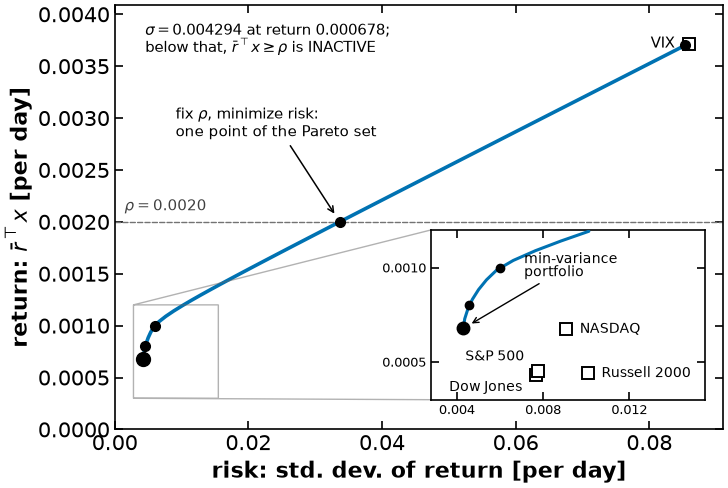

In [10]:
# The PLOTTING function: it takes the extracted results, not the Pyomo model.
#
# Everything it needs is in `results`, and nothing else -- no model, no solver,
# no data file. That is what lets you re-run this one cell as many times as it
# takes to get the labels where you want them, without waiting for 65 solves.


def plot_efficient_frontier(results):
    """Risk against return, with the epsilon-constraint construction drawn out.

    The FLAT LEFT END IS THE POINT. The minimum-variance portfolio already
    returns more than a small rho asks for, so there the constraint
    rbar^T x >= rho is inactive and every rho below it returns the same
    portfolio. An inequality you wrote down need not cost you a degree of
    freedom.
    """
    frontier = pyr.as_dataframe(results["frontier"])
    assets = pyr.as_dataframe(results["assets"])
    marks = pyr.as_dataframe(results["marks"])
    mv = results["min_variance"]
    demo = results["epsilon_demo"]

    sd_min, ret_min = mv["std_dev"], mv["return"]
    blue = "#0072B2"  # Okabe-Ito; the frontier is the only coloured series

    fig, ax = plt.subplots(figsize=(7.6, 5.2))
    ax.plot(frontier["std_dev"], frontier["rho"], color=blue, linestyle="-",
            linewidth=2.6, zorder=3)

    def draw_assets(axis, placement, fontsize=11):
        """The five indices as open squares, directly labelled.

        Every one of them lies to the RIGHT of the frontier at its own return.
        That gap is diversification, and it is the reason to solve the QP.
        `placement` maps ticker -> (dx, dy, ha) in points; a ticker absent from
        it is not drawn on this axis.
        """
        for _, row in assets.iterrows():
            if row["ticker"] not in placement:
                continue
            dx, dy, ha = placement[row["ticker"]]
            axis.plot([row["std_dev"]], [row["mean_return"]], marker="s",
                      markersize=8, markerfacecolor="white",
                      markeredgecolor="black", markeredgewidth=1.4,
                      linestyle="none", zorder=4)
            axis.annotate(row["name"], xy=(row["std_dev"], row["mean_return"]),
                          xytext=(dx, dy), textcoords="offset points",
                          fontsize=fontsize, ha=ha, va="center")

    draw_assets(ax, {"VIX": (-10, 0, "right")})

    # The tabulated rho values, and the minimum-variance corner.
    ax.plot(marks["std_dev"], marks["rho"], marker="o", markersize=7,
            color="black", linestyle="none", zorder=5)
    ax.plot([sd_min], [ret_min], marker="o", markersize=10, color="black",
            linestyle="none", zorder=5)

    # --- INSET: the four equity indices and the corner of the frontier ------
    # VIX is ten times as volatile as any of the others, so on one linear axis
    # the whole interesting part of the frontier -- and four of the five data
    # points -- collapses into the bottom-left corner.
    axin = ax.inset_axes([0.52, 0.07, 0.45, 0.40])
    x_in, y_in = (0.0028, 0.0155), (0.00030, 0.00120)
    keep = frontier["rho"] <= y_in[1]
    axin.plot(frontier["std_dev"][keep], frontier["rho"][keep], color=blue,
              linestyle="-", linewidth=2.2, zorder=3)
    # ha chosen per point: the four sit within 0.0024 of each other in risk and
    # within 0.00025 in return, so every label needs its own side.
    draw_assets(axin, {"DJI": (-10, -9, "right"), "GSPC": (-10, 10, "right"),
                       "RUT": (10, 0, "left"), "IXIC": (10, 0, "left")},
                fontsize=10)
    axin.plot([sd_min], [ret_min], marker="o", markersize=9, color="black",
              linestyle="none", zorder=5)
    axin.annotate("min-variance\nportfolio", xy=(sd_min, ret_min),
                  xytext=(0.34, 0.88), textcoords="axes fraction", fontsize=10,
                  ha="left", va="top", linespacing=1.05,
                  arrowprops=dict(arrowstyle="->", color="black",
                                  linewidth=1.0, shrinkB=7.0))
    inset_marks = marks[marks["rho"] <= y_in[1]]
    axin.plot(inset_marks["std_dev"], inset_marks["rho"], marker="o",
              markersize=6, color="black", linestyle="none", zorder=5)
    axin.set_xlim(*x_in)
    axin.set_ylim(*y_in)
    axin.tick_params(labelsize=9)
    axin.set_xticks([0.004, 0.008, 0.012])
    axin.set_yticks([0.0005, 0.0010])
    ax.indicate_inset_zoom(axin, edgecolor="0.4", linewidth=1.0)

    ax.annotate(
        f"$\\sigma = {sd_min:.6f}$ at return ${ret_min:.6f}$;\n"
        r"below that, $\bar{r}^{\top} x \geq \rho$ is INACTIVE",
        xy=(0.05, 0.96), xycoords="axes fraction", fontsize=10.5,
        ha="left", va="top", linespacing=1.15)

    # --- one epsilon-constraint solve, drawn out ---------------------------
    ax.axhline(demo["rho"], color="0.45", linewidth=1.0, linestyle="--", zorder=1)
    ax.annotate(f"$\\rho = {demo['rho']:.4f}$",
                xy=(ax.get_xlim()[0], demo["rho"]), xytext=(6, 5),
                textcoords="offset points", fontsize=11, ha="left",
                va="bottom", color="0.25")
    ax.annotate("fix $\\rho$, minimize risk:\none point of the Pareto set",
                xy=(demo["std_dev"], demo["rho"]), xytext=(0.10, 0.72),
                textcoords="axes fraction", fontsize=10.5, ha="left",
                va="center", linespacing=1.15,
                arrowprops=dict(arrowstyle="->", color="black", linewidth=1.1,
                                shrinkB=7.0))

    ax.set_xlabel("risk: std. dev. of return [per day]")
    ax.set_ylabel("return: $\\bar{r}^{\\top} x$ [per day]")
    ax.set_xlim(0.0, 1.06 * max(assets["std_dev"].max(),
                                frontier["std_dev"].max()))
    ax.set_ylim(0.0, 1.10 * assets["mean_return"].max())
    fig.tight_layout()
    return fig


fig = plot_efficient_frontier(results)

# Save the figure as PNG and PDF. A no-op on Colab, where there is nowhere to
# write it.
pyr.save_figure(fig, "portfolio-efficient-frontier");


### The required return is not always binding

The **flat left-hand end** of the frontier is the point. The minimum-variance
portfolio already returns more per day than a small $\rho$ demands, so at those
$\rho$ the constraint $\bar{r}^T x \geq \rho$ is **inactive** --- deleting it
would not change the answer, and every $\rho$ below the minimum-variance return
buys back the same portfolio.

An inequality constraint you wrote down need not cost you a degree of freedom.
Whether it does is a property of the *solution*, not of the model you wrote down.


In [11]:
# Read off the sweep above -- no new solve.
print(
    f"The minimum-variance portfolio returns {ret_min:.6f} per day, so the constraint\n"
    f"r_avg^T x >= 0.0005 is INACTIVE there ({ret_min:.6f} > 0.0005)."
)

print("\nWhere the money goes in the minimum-variance portfolio:")
for i, w in x_min.items():
    print(f"  {i:>5s}  {w * 100:6.2f}%")

The minimum-variance portfolio returns 0.000678 per day, so the constraint
r_avg^T x >= 0.0005 is INACTIVE there (0.000678 > 0.0005).

Where the money goes in the minimum-variance portfolio:
    DJI   14.95%
   GSPC   78.09%
   IXIC    0.00%
    RUT    0.00%
    VIX    6.96%


## What about uncertainty?

Lecture 1 asked this of the battery model and answered it with a table of six responses --- *ignore
it*, *explore it*, *learn it*, *reduce it*, *model it*, *protect against it*. Everything above took
the first one. That is what deterministic optimization is, and there is nothing wrong with it, but it
is a **choice** and it is worth seeing the size of what was set aside.

Neither $\bar{r}$ nor $\Sigma_r$ was given to us: both were **estimated** from historical daily
returns. They are therefore random variables in their own right, and we can say how uncertain they
are. The standard error of a mean estimated from $n$ observations is $s_i / \sqrt{n}$.


In [12]:
se = R.std(axis=0) / np.sqrt(len(R))

summary = pd.DataFrame({"rbar": R_avg, "standard error": se, "ratio": R_avg / se})
display(summary.round(6))

,rbar,standard error,ratio
DJI,0.000432,0.000216,1.995516
GSPC,0.000454,0.000219,2.071757
IXIC,0.000674,0.000255,2.637039
RUT,0.000440,0.000284,1.551509
VIX,0.003718,0.002421,1.535562


Every mean return in the model is known only to within roughly a factor of two of itself. The
constraint $\bar{r}^T x \geq \rho$ has *coefficients* that wobble by half their own size --- and we
then solved to six significant figures.

**Optimizing a model to a precision its data cannot support is the most common way to be confidently
wrong.**

Two caveats on the table above, both of which matter:

1. $s_i / \sqrt{n}$ assumes the daily returns are independent and identically distributed. Financial
   returns are neither.
2. The standard error is itself an estimate.

**So which of the six responses do you want?** This notebook *ignored* the uncertainty. The rest of
the course takes the others in turn: **explore it** with sensitivity analysis and the KKT
multipliers, **learn it** with parameter estimation, **reduce it** with optimal experimental design,
and **model it** with stochastic programming. Each of those is a different optimization problem ---
not a post-processing step you bolt onto this one.


## Take away messages

* A quadratic objective with linear constraints is a **quadratic program**. If the Hessian is
  positive semidefinite the problem is convex, and a local solution is a global solution.
* Contrast with circle packing: same solver, but there the answer depends on where you start, and
  here it does not.
* An inequality constraint that is **inactive** at the solution costs you nothing. Whether it is
  active is a property of the *solution*, not of the model you wrote down --- and it is what makes
  the left-hand end of the efficient frontier flat.
* **Solve, extract, plot** are three steps, not one. Archive the extracted numbers and you can
  redraw the figure without re-solving anything.
* **Solver tolerance is a property of what you are going to do with the answer**, not of the model.
  Six printed decimals need a tighter solve than the default gives you.
* Parameters estimated from data carry uncertainty. Report it, or at least know it --- and choose
  deliberately which of Lecture 1's six responses to it you are taking.
